# Frozen ESM-2 and exploratory motifs

Summarizes bounded supporting analyses without converting them into mechanistic claims.

**Scope:** consumes registered artifacts; no model refitting is performed in this publication notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'publication' else Path.cwd().resolve()
if not (PROJECT / '05_results').exists():
    PROJECT = Path('outputs/CBAC-D-26-03155_revision/06_canonical_revision_project').resolve()
PRIOR = PROJECT.parent / '04_reproducible_analysis/artifacts'
PUB = PROJECT / '05_results/validated/publication_outputs'
TABLES, FIGURES = PUB / 'tables', PUB / 'figures'
TABLES.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)

def read_csv(path, required):
    assert path.exists(), f'Missing registered artifact: {path}'
    df = pd.read_csv(path)
    missing = set(required) - set(df.columns)
    assert not missing, f'{path.name}: missing columns {sorted(missing)}'
    return df

plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 300, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
SPLIT_ORDER = ['exact', 'cluster', 'temporal']


In [2]:
esm=read_csv(PRIOR/'esm2_frozen/metrics.csv',['split','model','pr_auc','roc_auc'])
rf=read_csv(PROJECT/'05_results/validated/corrected_per_design_tuning/metrics.csv',['split','model','pr_auc']).query("model=='random_forest'")
comp=esm[['split','pr_auc']].rename(columns={'pr_auc':'esm2_frozen_pr_auc'}).merge(rf[['split','pr_auc']].rename(columns={'pr_auc':'rf_pr_auc'}),on='split')
mot=read_csv(PRIOR/'motif_analysis/summary.csv',['split','selected_motifs','heldout_fdr_below_0_05','direction_consistent_count'])
comp.to_csv(TABLES/'table_05_esm2_comparison.csv',index=False); mot.to_csv(TABLES/'table_05b_motif_summary.csv',index=False)
display(comp); display(mot)

,split,esm2_frozen_pr_auc,rf_pr_auc
0,exact,0.217433,0.472033
1,cluster,0.194439,0.404308
2,temporal,0.146630,0.144794


,split,vocabulary_size,nonzero_coefficients,selected_motifs,heldout_fdr_below_0_05,direction_consistent_count
0,exact,29398,527,100,5,61
1,cluster,29171,522,100,9,57
2,temporal,29906,543,100,0,40


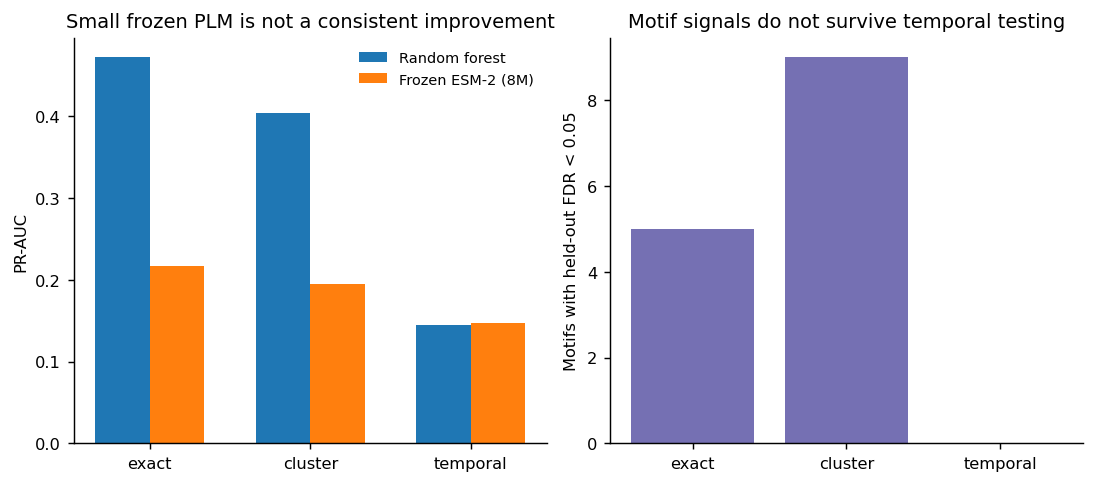

In [3]:
fig,axs=plt.subplots(1,2,figsize=(8.5,3.8)); x=np.arange(3); width=.34
axs[0].bar(x-width/2,comp.set_index('split').loc[SPLIT_ORDER].rf_pr_auc,width,label='Random forest'); axs[0].bar(x+width/2,comp.set_index('split').loc[SPLIT_ORDER].esm2_frozen_pr_auc,width,label='Frozen ESM-2 (8M)')
axs[0].set_xticks(x,SPLIT_ORDER); axs[0].set_ylabel('PR-AUC'); axs[0].set_title('Small frozen PLM is not a consistent improvement'); axs[0].legend(frameon=False,fontsize=8)
q=mot.set_index('split').loc[SPLIT_ORDER]; axs[1].bar(x,q.heldout_fdr_below_0_05,color='#7570B3'); axs[1].set_xticks(x,SPLIT_ORDER); axs[1].set_ylabel('Motifs with held-out FDR < 0.05'); axs[1].set_title('Motif signals do not survive temporal testing')
fig.tight_layout(); fig.savefig(FIGURES/'figure_04_esm2_motifs.png'); plt.show()

**Interpretation.** This experiment uses frozen mean embeddings from a small ESM-2 model with logistic regression; it is neither fine-tuning nor a comprehensive PLM benchmark. Motifs are exploratory associations, and the absence of reliable HLA restriction prevents defensible anchor interpretation.